# Chest X-Ray Classification using PCA + XGBoost

This experiment applies Principal Component Analysis (PCA) before XGBoost classification.

PCA reduces the dimensionality of the image feature space while preserving most of the information contained in the original images. The reduced features are then used to train an XGBoost classifier.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score
)

from xgboost import XGBClassifier

print("Libraries imported successfully.")

Libraries imported successfully.


## Dataset Loading and Preprocessing

The Chest X-Ray dataset is loaded from the training and testing folders.

Images are converted to grayscale, resized to 200×200 pixels, flattened into feature vectors, normalized, and prepared for PCA-based dimensionality reduction.

In [2]:
train_normal_path = "/mnt/c/ML Projects/Medical-Image-Classification-Projects/Exersize-2(ChestXRay)/archive/chest_xray/train/NORMAL"
train_pneumonia_path = "/mnt/c/ML Projects/Medical-Image-Classification-Projects/Exersize-2(ChestXRay)/archive/chest_xray/train/PNEUMONIA"

test_normal_path = "/mnt/c/ML Projects/Medical-Image-Classification-Projects/Exersize-2(ChestXRay)/archive/chest_xray/test/NORMAL"
test_pneumonia_path = "/mnt/c/ML Projects/Medical-Image-Classification-Projects/Exersize-2(ChestXRay)/archive/chest_xray/test/PNEUMONIA"

print("Dataset paths loaded successfully.")

Dataset paths loaded successfully.


## Image Loading

Images are loaded from the dataset folders, converted to grayscale,
resized to 200×200 pixels, and assigned labels.

Label Encoding:

- 0 → Normal
- 1 → Pneumonia

In [3]:
def load_images(folder_path, label):

    images = []
    labels = []

    for file in os.listdir(folder_path):

        image_path = os.path.join(folder_path, file)

        image = cv2.imread(
            image_path,
            cv2.IMREAD_GRAYSCALE
        )

        if image is None:
            continue

        image = cv2.resize(
            image,
            (200, 200)
        )

        images.append(image)
        labels.append(label)

    return images, labels

## Dataset Creation

The Normal and Pneumonia images are combined into a single dataset.

The resulting dataset is converted into NumPy arrays and prepared for feature extraction and dimensionality reduction.

In [4]:
normal_train_images, normal_train_labels = load_images(
    train_normal_path,
    0
)

pneumonia_train_images, pneumonia_train_labels = load_images(
    train_pneumonia_path,
    1
)

normal_test_images, normal_test_labels = load_images(
    test_normal_path,
    0
)

pneumonia_test_images, pneumonia_test_labels = load_images(
    test_pneumonia_path,
    1
)

print("Images loaded successfully.")

Images loaded successfully.


## Feature Preparation

XGBoost requires a two-dimensional feature matrix.

Each image is:

1. Flattened into a feature vector.
2. Converted to floating-point format.
3. Normalized to the range [0,1].

The resulting matrix is then used as input for PCA.

In [5]:
xtrain = np.array(
    normal_train_images + pneumonia_train_images
)

ytrain = np.array(
    normal_train_labels + pneumonia_train_labels
)

xtest = np.array(
    normal_test_images + pneumonia_test_images
)

ytest = np.array(
    normal_test_labels + pneumonia_test_labels
)

xtrain = xtrain.reshape(
    xtrain.shape[0],
    -1
)

xtest = xtest.reshape(
    xtest.shape[0],
    -1
)

xtrain = xtrain.astype("float32") / 255.0
xtest = xtest.astype("float32") / 255.0

print("Training Feature Shape:", xtrain.shape)
print("Testing Feature Shape :", xtest.shape)

Training Feature Shape: (5216, 40000)
Testing Feature Shape : (624, 40000)


## Principal Component Analysis (PCA)

PCA is applied to reduce the dimensionality of the image feature space.

Instead of using all 40,000 pixel features, PCA retains only the principal components required to preserve 98% of the variance in the dataset. This reduces computational complexity while preserving most of the information contained in the images.

In [6]:
pca = PCA(
    n_components=0.98,
    random_state=42
)

xtrain_pca = pca.fit_transform(xtrain)

xtest_pca = pca.transform(xtest)

print("Original Features :", xtrain.shape[1])
print("Reduced Features  :", xtrain_pca.shape[1])

Original Features : 40000
Reduced Features  : 1723


## XGBoost Training on PCA Features

The reduced PCA feature representation is used to train an XGBoost classifier.

This approach evaluates whether dimensionality reduction can improve efficiency while maintaining classification performance.

In [7]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(
    xtrain_pca,
    ytrain
)

print("XGBoost training completed.")

XGBoost training completed.


## Model Evaluation

The PCA + XGBoost model is evaluated using training and testing accuracy to assess its performance after dimensionality reduction.

In [8]:
ytrain_pred = xgb_model.predict(xtrain_pca)
ytest_pred = xgb_model.predict(xtest_pca)

train_accuracy = accuracy_score(ytrain, ytrain_pred)
test_accuracy = accuracy_score(ytest, ytest_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy : {test_accuracy:.4f}")

Training Accuracy: 1.0000
Testing Accuracy : 0.7548


## Classification Report

The classification report summarizes precision, recall, and F1-score for each class and provides a detailed view of model performance after PCA-based dimensionality reduction.

In [9]:
print("\nClassification Report:\n")
print(classification_report(ytest, ytest_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.38      0.54       234
           1       0.73      0.98      0.83       390

    accuracy                           0.75       624
   macro avg       0.82      0.68      0.69       624
weighted avg       0.79      0.75      0.72       624



## Confusion Matrix

A confusion matrix is generated to visualize the classification performance of the PCA + XGBoost model and identify misclassifications between Normal and Pneumonia classes.

In [10]:
cm = confusion_matrix(ytest, ytest_pred)

print(cm)

[[ 90 144]
 [  9 381]]


## Confusion Matrix Visualization

The confusion matrix is visualized using a heatmap to better understand the classification behavior of the PCA + XGBoost model.

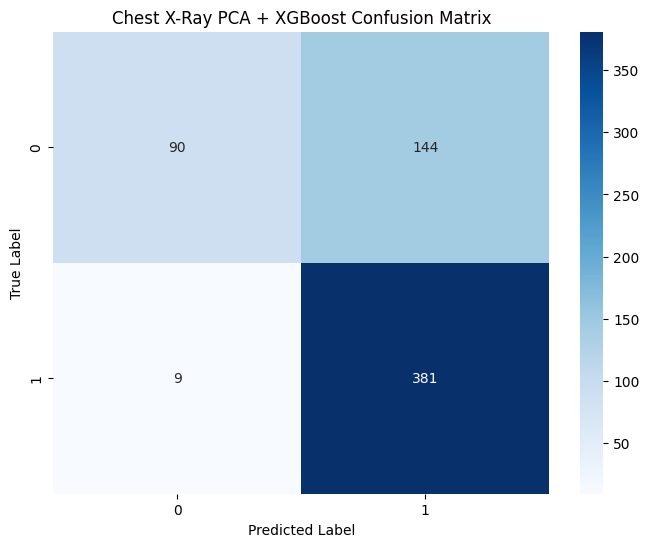

In [11]:
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Chest X-Ray PCA + XGBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## Evaluation Metrics

The PCA + XGBoost model is evaluated using:

- Accuracy
- F1 Score
- Sensitivity (Recall)
- Specificity

These metrics provide a comprehensive assessment of classification performance after dimensionality reduction.

In [12]:
f1 = f1_score(ytest, ytest_pred, average="weighted")

sensitivity = recall_score(
    ytest,
    ytest_pred,
    average="weighted"
)

cm = confusion_matrix(ytest, ytest_pred)

specificity_list = []

for i in range(len(cm)):

    tp = cm[i, i]

    fn = np.sum(cm[i, :]) - tp

    fp = np.sum(cm[:, i]) - tp

    tn = np.sum(cm) - (tp + fn + fp)

    specificity = tn / (tn + fp)

    specificity_list.append(specificity)

specificity = np.mean(specificity_list)

print(f"Accuracy    : {test_accuracy*100:.2f}%")
print(f"F1 Score    : {f1*100:.2f}%")
print(f"Sensitivity : {sensitivity*100:.2f}%")
print(f"Specificity : {specificity*100:.2f}%")

Accuracy    : 75.48%
F1 Score    : 72.32%
Sensitivity : 75.48%
Specificity : 68.08%


## Training Percentage Experiment

The effect of training data size on PCA + XGBoost performance is analyzed.

The model is trained using:

- 20% of training data
- 40% of training data
- 60% of training data
- 80% of training data

The resulting accuracies are compared to observe performance trends.

In [15]:
training_sizes = [0.2, 0.4, 0.6, 0.8]

from sklearn.model_selection import train_test_split

xgb_train_scores = []
xgb_test_scores = []

for size in training_sizes:

    x_small, _, y_small, _ = train_test_split(
        xtrain_pca,
        ytrain,
        train_size=size,
        random_state=10,
        stratify=ytrain
    )

    xgb_model = XGBClassifier(
        objective='binary:logistic',
        random_state=10,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1
    )

    xgb_model.fit(x_small, y_small)

    train_acc = xgb_model.score(x_small, y_small)
    test_acc = xgb_model.score(xtest_pca, ytest)

    xgb_train_scores.append(train_acc)
    xgb_test_scores.append(test_acc)

    print(f"\nTraining Size: {int(size*100)}%")
    print(f"Samples Used: {len(x_small)}")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy : {test_acc:.4f}")


Training Size: 20%
Samples Used: 1043
Training Accuracy: 1.0000
Testing Accuracy : 0.7115

Training Size: 40%
Samples Used: 2086
Training Accuracy: 1.0000
Testing Accuracy : 0.7388

Training Size: 60%
Samples Used: 3129
Training Accuracy: 1.0000
Testing Accuracy : 0.7484

Training Size: 80%
Samples Used: 4172
Training Accuracy: 1.0000
Testing Accuracy : 0.7532


## Accuracy Visualization

The testing accuracies obtained using different training percentages are plotted to visualize the impact of training data size on PCA + XGBoost performance.

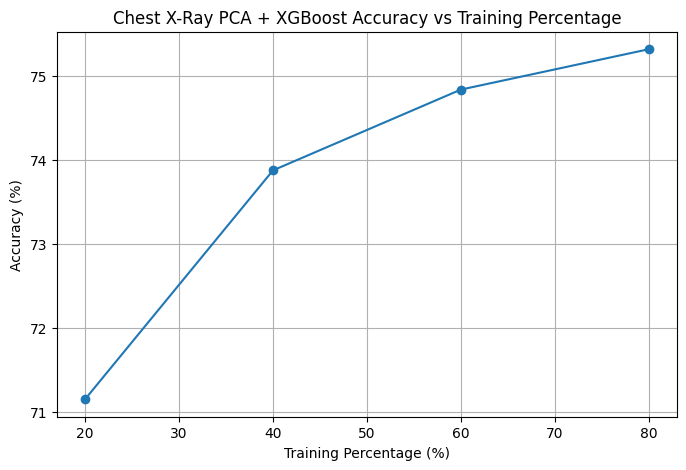

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    [20, 40, 60, 80],
    [x * 100 for x in xgb_test_scores],
    marker='o'
)

plt.title("Chest X-Ray PCA + XGBoost Accuracy vs Training Percentage")
plt.xlabel("Training Percentage (%)")
plt.ylabel("Accuracy (%)")
plt.grid(True)

plt.show()